# Sentiment analysis

- How did overall emotions evolve before, during, and after the wildfire?
- Which specific events triggered spikes in positive or negative sentiment?
- How do different communities/users express sentiment differently?
- Are there trends or patterns in sentiment across time (daily/weekly)?
- (Extra) Can we detect misinformation, panic, or calming narratives from sentiment shifts?

In [1]:
import json
from datetime import datetime
from collections import defaultdict
from preprocess_data import preprocess_posts_and_interactions
import pandas as pd
import nltk
nltk.download('vader_lexicon')
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/jyanes/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
posts, interact_filtered = preprocess_posts_and_interactions("../data/bluesky/posts_all.jsonl", "../data/bluesky/interactions_all.jsonl")

=== dataset cleaning & dedupe ===
Rows after scanning-spam filter (before dedupe): 8839
Rows after dedupe by uri: 8836

=== URI / interaction summary (unique-URI basis) ===
Total unique clean posts: 8,836
Unique post URIs that appear as interaction targets (in our interact file): 5,267
Unique post URIs with zero interactions: 3,569
Check sum (unique targets + lonely) == total_unique_posts -> 8836 == 8836

=== interactions (filtered to posts we retained) ===
Total interaction rows (original interactions file): 403,598
Interaction rows after filtering to dst_uri in our posts: 368,990
Interaction types (filtered):
like    : 282,685
repost  : 77,339
reply   : 8,966

Distinct users (authors in posts ∪ src_did of filtered interactions): 182,087

=== first 10 cleaned posts (after filtering & dedupe) ===
                                                                                                                           “california require insurers offer home coverage wildfire-prone areas

In [9]:
def add_vader_daily_sentiment(posts: pd.DataFrame):
    """
    Adds VADER sentiment (neg, neu, pos, compound) to posts and computes daily averages + post counts.

    Returns:
        posts: original posts with 'sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound', 'date'
        daily_sentiment: DataFrame with columns ['date', 'mean_neg', 'mean_neu', 'mean_pos', 'mean_compound', 'post_count']
    """
    analyzer = SentimentIntensityAnalyzer()

    # ---------- sentiment ----------
    vader_scores = posts['clean_text'].apply(lambda t: analyzer.polarity_scores(t))
    posts['sentiment_neg'] = vader_scores.apply(lambda x: x['neg'])
    posts['sentiment_neu'] = vader_scores.apply(lambda x: x['neu'])
    posts['sentiment_pos'] = vader_scores.apply(lambda x: x['pos'])
    posts['sentiment_compound'] = vader_scores.apply(lambda x: x['compound'])

    # ---------- convert timestamps ----------
    posts['date'] = pd.to_datetime(posts['created_at'], utc=True, errors='coerce').dt.date
    posts = posts.dropna(subset=['date']).reset_index(drop=True)

    # ---------- daily stats ----------
    daily_sentiment = posts.groupby('date').agg(
        mean_neg=('sentiment_neg', 'mean'),
        mean_neu=('sentiment_neu', 'mean'),
        mean_pos=('sentiment_pos', 'mean'),
        mean_compound=('sentiment_compound', 'mean'),
        post_count=('sentiment_compound', 'size')
    ).reset_index()

    return posts, daily_sentiment

# --- usage ---
posts_with_sentiment, daily_sentiment = add_vader_daily_sentiment(posts)
print(daily_sentiment.head())

         date  mean_neg  mean_neu  mean_pos  mean_compound  post_count
0  2025-01-01  0.007625  0.943750  0.048625       0.096312           8
1  2025-01-02  0.127111  0.806111  0.066778      -0.190900           9
2  2025-01-03  0.085000  0.764000  0.151200       0.148910          10
3  2025-01-04  0.140538  0.743923  0.115538      -0.044000          13
4  2025-01-05  0.107200  0.861200  0.031600      -0.236180           5


In [ ]:
# ---------------------------
# Select posts from Jan 23
# ---------------------------
target_date = pd.to_datetime("2025-01-23").date()
day_posts = posts_with_sentiment[posts_with_sentiment['date'] == target_date]

if len(day_posts) == 0:
    print("No posts found on Jan 23.")
else:
    # Most negative post
    most_negative = day_posts.loc[day_posts['sentiment_compound'].idxmin()]

    # Find the post closest to the mean sentiment for Jan 23
    mean_sentiment = day_posts['sentiment_compound'].mean()
    closest_to_mean = day_posts.loc[(day_posts['sentiment_compound'] - mean_sentiment).abs().idxmin()]

    print("\n=== MOST NEGATIVE POST (Jan 23) ===")
    print("Score:", most_negative['sentiment_compound'])
    print("Text:", most_negative['clean_text'])

    print("\n=== AVERAGE POST (Closest to Mean Sentiment, Jan 23) ===")
    print("Mean sentiment for day:", mean_sentiment)
    print("Score:", closest_to_mean['sentiment_compound'])
    print("Text:", closest_to_mean['clean_text'])



=== MOST NEGATIVE POST (Jan 23) ===
Score: -0.9056
Text: critical fire weather alert: southern california facing dangerous winds extreme fire risk. heed evacuation orders local authorities. follow guidance emergency officials ready.ca.gov

=== AVERAGE POST (Closest to Mean Sentiment, Jan 23) ===
Mean sentiment for day: -0.16033333333333333
Score: -0.1531
Text: california firefighters battling wildfire sweeping exclusive los angeles hillside dotted celebrity homes


Index(['uri', 'cid', 'created_at', 'indexed_at', 'author_did', 'author_handle',
       'text', 'langs', 'reply_to', 'quoted', 'like_count', 'repost_count',
       'clean_text', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos',
       'sentiment_compound', 'date'],
      dtype='object')


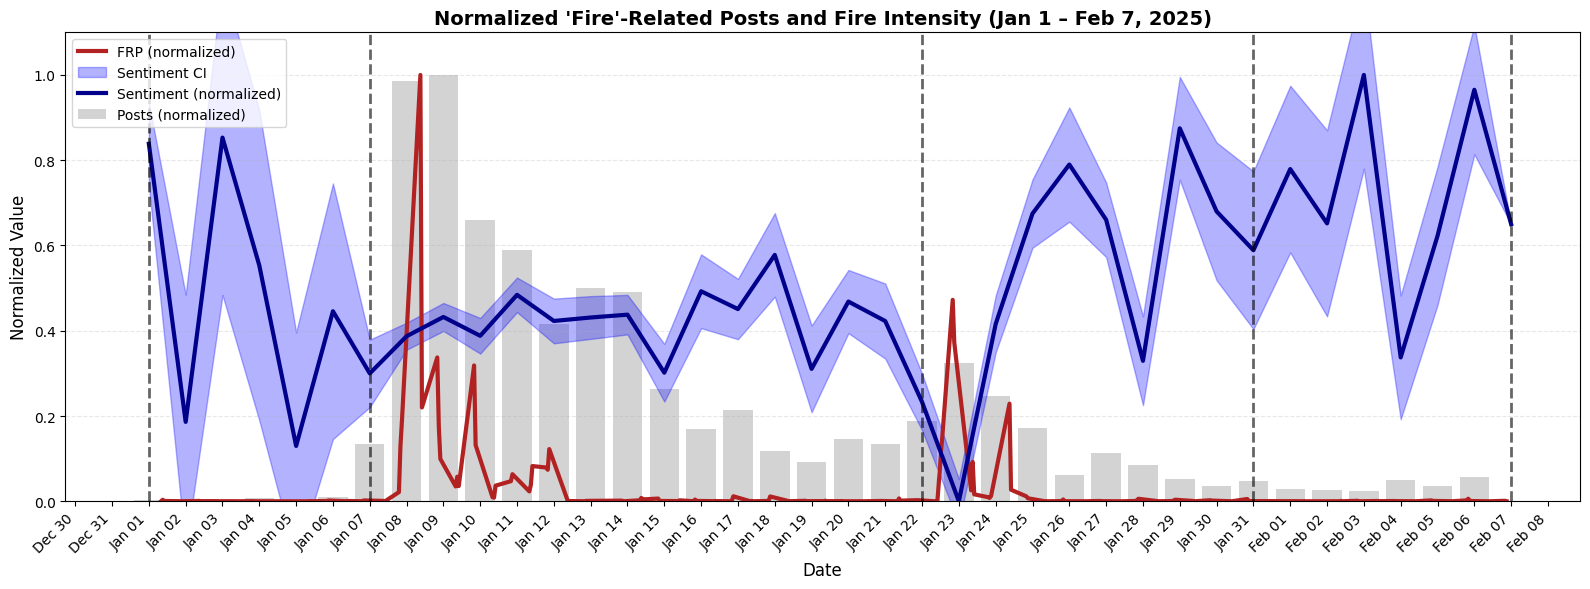

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import numpy as np

# ---------------------------
# Define start and end dates
# ---------------------------
start_date = pd.Timestamp("2025-01-01", tz='UTC')
end_date   = pd.Timestamp("2025-02-07", tz='UTC')

# ---------------------------
# Load fire detection data
# ---------------------------
fire_data = pd.read_csv('../data/nasa/combined_fire_detections.csv')
fire_data['datetime'] = pd.to_datetime(fire_data['datetime'], utc=True)
fire_data['hour'] = fire_data['datetime'].dt.floor('h')
fire_data = fire_data[(fire_data['hour'] >= start_date) & (fire_data['hour'] <= end_date)]

fire_by_hour = fire_data.groupby('hour').agg({
    'frp': 'sum',          # Total fire radiative power
    'brightness': 'count'  # Number of detections
}).reset_index()
fire_by_hour.columns = ['hour', 'total_frp', 'detection_count']

# ---------------------------
# Load Bluesky posts data
# ---------------------------
posts['indexed_at'] = pd.to_datetime(posts['indexed_at'], utc=True)
posts = posts[(posts['indexed_at'] >= start_date) & (posts['indexed_at'] <= end_date)]
posts['date'] = posts['indexed_at'].dt.date
posts_by_day = posts.groupby('date').size().reset_index(name='post_count')

# ---------------------------
# Prepare daily sentiment (VADER already computed)
# ---------------------------
# Assume daily_sentiment DataFrame exists: columns ['date', 'mean_compound']
# Also assume we have per-post sentiment to compute SEM
print(posts.columns)
if 'sentiment_compound' in posts.columns:
    # Compute mean and SEM per day
    sentiment_stats = posts.groupby('date')['sentiment_compound'].agg(['mean','std','count']).reset_index()
    sentiment_stats['sem'] = sentiment_stats['std'] / np.sqrt(sentiment_stats['count'])
else:
    # fallback if daily_sentiment only
    sentiment_stats = daily_sentiment.copy()
    sentiment_stats['sem'] = 0

# Reindex to include all days
all_days = pd.date_range(start=start_date.date(), end=end_date.date(), freq='D')
sentiment_stats = sentiment_stats.set_index('date').reindex(all_days).rename_axis('date').reset_index()
sentiment_stats['mean'] = sentiment_stats['mean'].fillna(0)
sentiment_stats['sem'] = sentiment_stats['sem'].fillna(0)

# Normalize mean sentiment for plotting
sentiment_stats['sentiment_norm'] = (
    (sentiment_stats['mean'] - sentiment_stats['mean'].min()) /
    (sentiment_stats['mean'].max() - sentiment_stats['mean'].min())
)
sentiment_stats['sem_norm'] = sentiment_stats['sem'] / (sentiment_stats['mean'].max() - sentiment_stats['mean'].min())

# ---------------------------
# Prepare fires metrics and normalize
# ---------------------------
fire_by_hour['total_frp_norm'] = (fire_by_hour['total_frp'] - fire_by_hour['total_frp'].min()) / \
                                 (fire_by_hour['total_frp'].max() - fire_by_hour['total_frp'].min())

# Normalize posts for histogram
posts_by_day['posts_norm'] = (posts_by_day['post_count'] - posts_by_day['post_count'].min()) / \
                             (posts_by_day['post_count'].max() - posts_by_day['post_count'].min())

# ---------------------------
# Plotting
# ---------------------------
fig, ax = plt.subplots(figsize=(16, 6))

# Histogram: normalized posts per day (gray background)
ax.bar(posts_by_day['date'], posts_by_day['posts_norm'], width=0.8,
       color='darkgray', alpha=0.5, label='Posts (normalized)')

# FRP normalized line
ax.plot(fire_by_hour['hour'], fire_by_hour['total_frp_norm'], color='firebrick', linewidth=3,
        marker=None, label='FRP (normalized)')

# Sentiment confidence band
upper = sentiment_stats['sentiment_norm'] + sentiment_stats['sem_norm']
lower = sentiment_stats['sentiment_norm'] - sentiment_stats['sem_norm']

ax.fill_between(sentiment_stats['date'], lower, upper,
                color='blue', alpha=0.3, label='Sentiment CI')

# Sentiment line
ax.plot(sentiment_stats['date'], sentiment_stats['sentiment_norm'],
        color='darkblue', linewidth=3, label='Sentiment (normalized)')

# Add vertical lines for key dates
key_dates = [pd.Timestamp("2025-01-01"), pd.Timestamp("2025-01-07"), 
             pd.Timestamp("2025-01-22"), pd.Timestamp("2025-01-31"), 
             pd.Timestamp("2025-02-07")]
for date in key_dates:
    ax.axvline(x=date.normalize(), color='black', linestyle='--', alpha=0.6, linewidth=2)

# X-axis formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Labels and legend
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Normalized Value', fontsize=12)
ax.set_ylim(0,1.1)
ax.set_title("Normalized 'Fire'-Related Posts and Fire Intensity (Jan 1 – Feb 7, 2025)",
             fontsize=14, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

- Confidence modification
- Pie charts modifications
- Send Krish Topic BERT code

### Analyze narratives from sentiment shifts

1. Selected valid posts for topic modeling: We created a mask to include only posts with non-empty clean_text. This prevents BERTopic from failing on empty/missing text.
2. Initialized all posts with a default topic label. We set `posts["topic"] = -1` for every row. -1 is BERTopic’s standard “outlier / no topic” label.
3. Ran BERTopic only on valid texts
4. Mapped topics back into the original dataframe. We reassigned the returned topic labels only to the rows included in the mask
5. Result: Every post now has a valid topic ID if BERTopic processed it, and `topic = -1` if it had no usable text or was an outlier

BERTopic extracts topics in three main steps:

1. **Document Embedding**

   * Each document (post) is converted into a dense vector using a **pretrained transformer model** (like BERT, RoBERTa, or Sentence-BERT).
   * These embeddings capture **semantic meaning** beyond just word frequency.

2. **Dimensionality Reduction**

   * The high-dimensional embeddings (768+ dims) are reduced to 5–50 dimensions using **UMAP**.
   * This preserves **local semantic structure**, making similar documents cluster together.

3. **Clustering & Topic Extraction**

   * Reduced embeddings are clustered using **HDBSCAN** (density-based clustering).
   * For each cluster, the **most representative words** are extracted via **c-TF-IDF**, which computes term importance within the cluster relative to the whole corpus.
   * Each cluster is then labeled as a “topic” with its top weighted words.

**Summary:**

* **Semantic embeddings → dimensionality reduction → density-based clustering → top words extraction**.
* Works well for short texts and evolving topics because it captures meaning, not just word frequency.

This is why BERTopic can find coherent topics even when words don’t overlap much.

In [5]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

# --- Initialize model ----------------------------------------------------------
topic_model = BERTopic(
    vectorizer_model=CountVectorizer(stop_words="english"),
    low_memory=True
)

# --- Clean text (ensure strings, no NaN) --------------------------------------
posts['clean_text'] = posts['clean_text'].fillna("").astype(str)

# --- Mask: valid rows with non-empty text -------------------------------------
mask = posts['clean_text'].str.strip().ne("")

# Extract only valid texts for BERTopic
texts = posts.loc[mask, 'clean_text'].tolist()

# --- Fit BERTopic --------------------------------------------------------------
topics, probs = topic_model.fit_transform(texts)

# --- Initialize topic column with placeholder for invalid rows -----------------
posts['topic'] = -1

# Assign topics back ONLY to rows with real text
posts.loc[mask, 'topic'] = topics

# --- Optional: inspect top words per topic ------------------------------------
topic_info = topic_model.get_topic_info()
print(topic_info.head())

# Example: show topic words
for t_id in topic_info['Topic'].head(5):
    print(f"\nTopic {t_id}")
    print(topic_model.get_topic(t_id))

/home/jyanes/socialgraphs_2025/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


   Topic  Count                                      Name  \
0     -1   2704  -1_wildfire_california_wildfires_angeles   
1      0    537           0_trump_aid_federal_republicans   
2      1    323               1_evacuation_safe_stay_zone   
3      2    206       2_palisades_pacific_residents_homes   
4      3    189           3_foundation_fund_donate_relief   

                                      Representation  \
0  [wildfire, california, wildfires, angeles, los...   
1  [trump, aid, federal, republicans, withhold, s...   
2  [evacuation, safe, stay, zone, hope, order, or...   
3  [palisades, pacific, residents, homes, 30000, ...   
4  [foundation, fund, donate, relief, cross, help...   

                                 Representative_Docs  
0  [bluesky's top 10 trending words past 10 minut...  
1  [republicans say want put conditions wildfire ...  
2  [friends california, please stay safe, follow ...  
3  [massive pacific palisades fire los angeles, c...  
4  [organizations fun

In [6]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import umap

# Ensure datetime
posts['date'] = pd.to_datetime(posts['created_at'], utc=True, errors='coerce').dt.date

# Define periods
periods = {
    "Jan 1–6": (pd.to_datetime("2025-01-01").date(), pd.to_datetime("2025-01-06").date()),
    "Jan 7–21": (pd.to_datetime("2025-01-07").date(), pd.to_datetime("2025-01-21").date()),
    "Jan 22–31": (pd.to_datetime("2025-01-22").date(), pd.to_datetime("2025-01-31").date()),
    "Feb 1–7": (pd.to_datetime("2025-02-01").date(), pd.to_datetime("2025-02-07").date())
}

# Dictionary to store results
period_topic_models = {}
period_topics_posts = {}

# Loop through each period
for label, (start, end) in periods.items():
    mask = (posts['date'] >= start) & (posts['date'] <= end) & (posts['clean_text'].str.strip().ne(""))
    texts = posts.loc[mask, 'clean_text'].tolist()
    
    if len(texts) < 5:  # UMAP requires at least 2 samples
        print(f"Skipping {label}: too few posts ({len(texts)})")
        continue
    
    # Determine n_neighbors dynamically
    n_neighbors = min(15, len(texts)-1) if len(texts) > 1 else 2

    # Create UMAP model with proper n_neighbors
    umap_model = umap.UMAP(n_neighbors=n_neighbors, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

    # Pass UMAP model to BERTopic
    topic_model = BERTopic(
        vectorizer_model=CountVectorizer(stop_words="english"),
        low_memory=True,
        umap_model=umap_model
    )

    # Fit
    topics, probs = topic_model.fit_transform(texts)
    
    # Assign topics back to the posts dataframe for this period
    posts.loc[mask, 'topic'] = topics
    
    # Store the model and topics for inspection
    period_topic_models[label] = topic_model
    period_topics_posts[label] = posts.loc[mask].copy()
    
    # Optional: print top topics
    print(f"\n=== Top Topics for {label} ===")
    topic_info = topic_model.get_topic_info().head(5)
    print(topic_info)


=== Top Topics for Jan 1–6 ===
   Topic  Count                                      Name  \
0     -1      8      -1_california_wildfire_shit_building   
1      0     33  0_california_insurance_coverage_wildfire   
2      1     19      1_southern_winds_wildfire_california   

                                      Representation  \
0  [california, wildfire, shit, building, plane, ...   
1  [california, insurance, coverage, wildfire, ho...   
2  [southern, winds, wildfire, california, condit...   

                                 Representative_Docs  
0  [heroism america california comes story herois...  
1  [california require insurance companies offer ...  
2  [gusty winds, low humidity hit southern califo...  

=== Top Topics for Jan 7–21 ===
   Topic  Count                                   Name  \
0     -1   2146  -1_wildfire_california_relief_climate   
1      0    330           0_evacuation_safe_stay_alert   
2      1    252        1_orders_acres_structures_eaton   
3      2    2

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_topic_bubbles(posts_df, topic_model, top_n=5, title=None):
    """
    Draw Agar.io-style topic bubbles.

    Parameters:
    -----------
    posts_df : pd.DataFrame
        DataFrame containing a 'topic' column.
    topic_model : BERTopic
        Fitted BERTopic model corresponding to posts_df.
    top_n : int
        Number of top populated topics to show.
    title : str or None
        Plot title.
    """
    # Exclude outlier topic -1
    valid_posts = posts_df[posts_df["topic"] != -1]
    if valid_posts.empty:
        print("No valid topics to display.")
        return

    # Count posts per topic and select top N
    topic_sizes = valid_posts["topic"].value_counts().head(top_n)
    top_topics = topic_sizes.index.tolist()
    sizes = topic_sizes.values

    # Get top words per topic
    topic_words = {t: topic_model.get_topic(t)[:5] for t in top_topics}

    # Compute bubble radii and positions (circular layout)
    radii = np.sqrt(sizes / np.pi)
    theta = np.linspace(0, 2*np.pi, len(top_topics), endpoint=False)
    xs = np.cos(theta) * (max(radii)*4)
    ys = np.sin(theta) * (max(radii)*4)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 12))

    for t_id, x, y, r in zip(top_topics, xs, ys, radii):
        # Draw bubble
        bubble = plt.Circle((x, y), r, alpha=0.25, color='steelblue')
        ax.add_patch(bubble)

        # Topic ID
        ax.text(x, y, f"Topic {t_id}", ha='center', va='center', fontsize=14, weight='bold')

        # Top words inside bubble
        words = topic_words[t_id]
        for i, (word, weight) in enumerate(words):
            ax.text(
                x,
                y - (i+1) * (r*0.35),  # stacked vertically
                word,
                ha='center', va='center',
                fontsize=10 + weight*40  # scale by importance
            )

    # Final styling
    ax.set_xlim(min(xs) - max(radii)*2, max(xs) + max(radii)*2)
    ax.set_ylim(min(ys) - max(radii)*2, max(ys) + max(radii)*2)
    ax.set_aspect('equal')
    ax.axis('off')

    if title:
        plt.title(title, fontsize=18)
    plt.show()

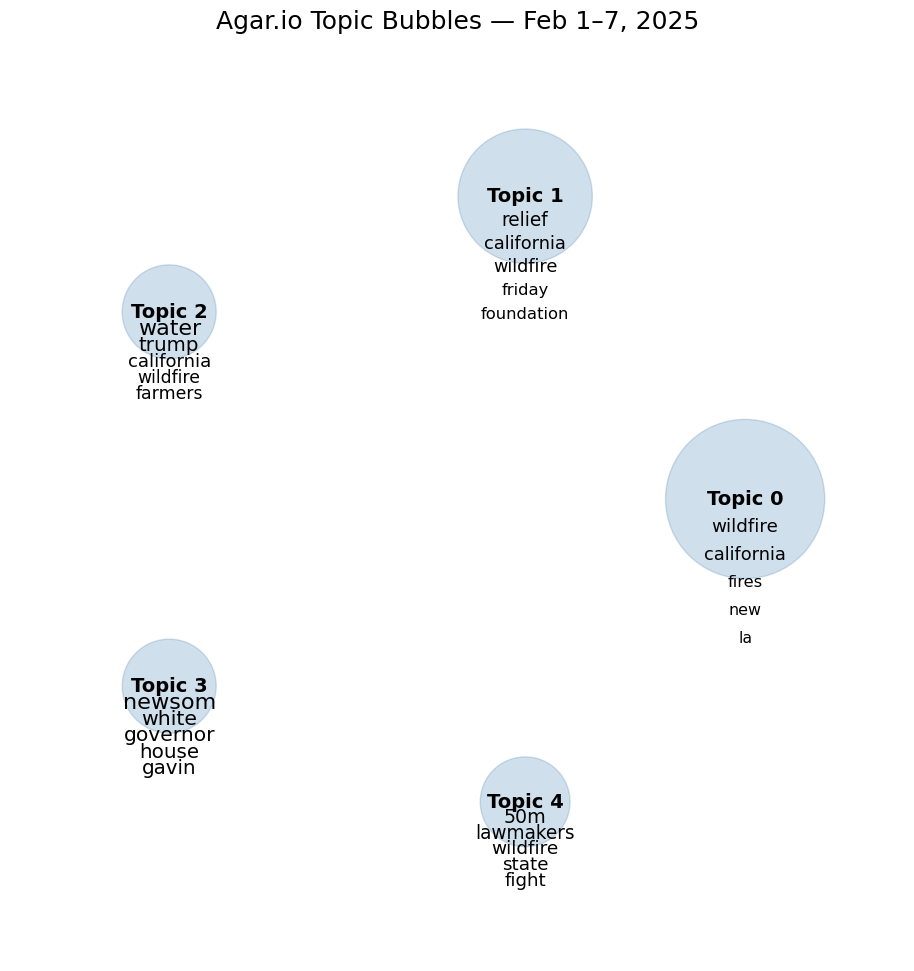

In [8]:
time_range = "Feb 1–7"
plot_topic_bubbles(
    posts_df=period_topics_posts[time_range],
    topic_model=period_topic_models[time_range],
    top_n=5,
    title=f"Agar.io Topic Bubbles — {time_range}, 2025"
)

### Post Classification: Emotions and Content Type

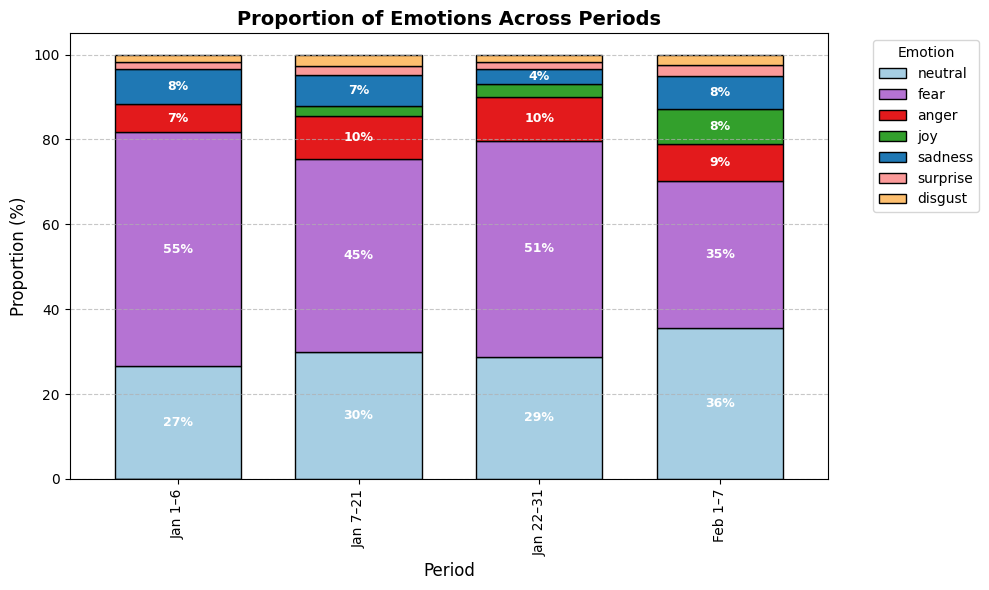

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# --- 1. ADD EMOTIONS TO PERIOD SUBSETS (if not already present) ---

CACHE_FILE = "emotion_cache.csv"

# Check if 'posts' variable exists, if not create a placeholder or skip
if 'posts' not in dir():
    print("Warning: 'posts' DataFrame not found. Please ensure it's defined in a previous cell.")
    posts = pd.DataFrame()

# A. Try to load from cache first
if len(posts) > 0 and 'emotions' not in posts.columns and os.path.exists(CACHE_FILE):
    print(f"Loading emotions from {CACHE_FILE}...")
    cached_df = pd.read_csv(CACHE_FILE)
    # Merge emotions back into 'posts' using the unique URI
    posts = posts.merge(cached_df[['uri', 'emotions']], on='uri', how='left')

# B. If 'emotions' is STILL missing (cache didn't exist or didn't cover these posts), run the model
if 'emotions' not in posts.columns or posts['emotions'].isnull().any():
    print("Cache not found or incomplete. Running emotion classification...")
    from transformers import pipeline
    
    # Run the model
    emotion_clf = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", return_all_scores=True)
    
    # Fill only missing emotions (in case cache was partial, though usually it's all or nothing)
    mask_missing = posts['emotions'].isnull() if 'emotions' in posts.columns else [True] * len(posts)
    
    # Apply model (this is the slow part)
    # Note: If 'emotions' column doesn't exist yet, we create it
    if 'emotions' not in posts.columns:
        posts['emotions'] = None
        
    posts.loc[mask_missing, 'emotions'] = posts.loc[mask_missing, 'text'].apply(
        lambda x: max(emotion_clf(x)[0], key=lambda d: d['score'])['label']
    )
# --- 2. PREPARE THE DATA ---

data_rows = []

# Define time ranges for grouping posts
time_ranges_dict = {
    "Jan 1–6": (pd.Timestamp("2025-01-01"), pd.Timestamp("2025-01-06")),
    "Jan 7–21": (pd.Timestamp("2025-01-07"), pd.Timestamp("2025-01-21")),
    "Jan 22–31": (pd.Timestamp("2025-01-22"), pd.Timestamp("2025-01-31")),
    "Feb 1–7": (pd.Timestamp("2025-02-01"), pd.Timestamp("2025-02-07"))
}

# Convert posts date column to datetime if it's not already
posts['date'] = pd.to_datetime(posts['date'], errors='coerce')

# Group posts by time period and count emotions
for period_name, (start, end) in time_ranges_dict.items():
    period_posts = posts[(posts['date'] >= start) & (posts['date'] <= end)]
    if len(period_posts) > 0 and 'emotions' in period_posts.columns:
        counts = period_posts['emotions'].value_counts()
        for emotion, count in counts.items():
            data_rows.append({'Period': period_name, 'Emotion': emotion, 'Count': count})

df_summary = pd.DataFrame(data_rows)

# Handle case where df_summary is empty
if len(df_summary) == 0:
    print("Warning: No emotion data found for the time periods. Check your 'posts' DataFrame and date formatting.")

# --- Prepare pivot table with percentages (assuming df_summary is ready) ---
emotion_order = ["neutral", "fear", "anger", "joy", "sadness", "surprise", "disgust"]
time_ranges = ["Jan 1–6", "Jan 7–21", "Jan 22–31", "Feb 1–7"]
color_map = {
    "neutral": "#a6cee3", "fear": "#b573d3", "anger": "#e31a1c",
    "joy": "#33a02c", "sadness": "#1f78b4", "surprise": "#fb9a99", "disgust": "#fdbf6f"
}

pivot_df = df_summary.pivot_table(index='Period', columns='Emotion', values='Count', fill_value=0)
pivot_df = pivot_df.reindex(index=time_ranges, columns=emotion_order, fill_value=0)
pivot_pct = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

# --- Plotting stacked bar ---
fig, ax = plt.subplots(figsize=(10, 6))

colors_list = [color_map[e] for e in emotion_order]

pivot_pct.plot(kind='bar', stacked=True, ax=ax, color=colors_list, edgecolor='black', width=0.7)

# --- Aesthetics ---
ax.set_title("Proportion of Emotions Across Periods", fontsize=14, fontweight='bold')
ax.set_xlabel("Period", fontsize=12)
ax.set_ylabel("Proportion (%)", fontsize=12)
ax.legend(title="Emotion", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# --- Optional: bar labels for percentages > threshold ---
for c in ax.containers:
    labels = [f'{v.get_height():.0f}%' if v.get_height() > 3 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=9, color='white', weight='bold')

plt.tight_layout()
plt.savefig("emotions_by_period_stacked.png")
plt.show()


Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


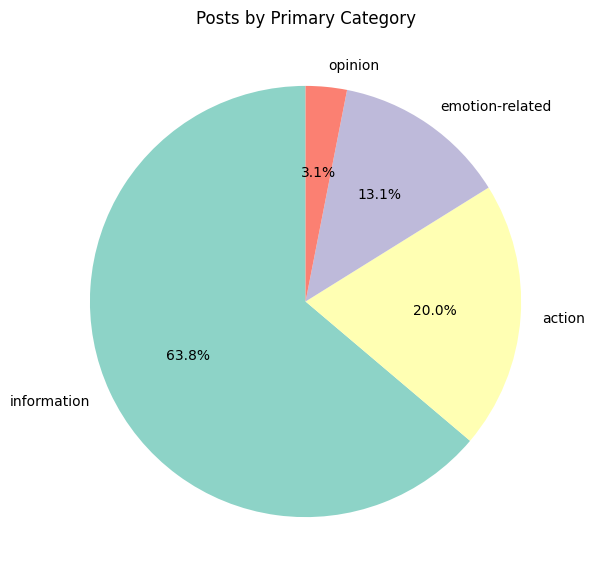

In [ ]:
from transformers import pipeline
import matplotlib.pyplot as plt
import pandas as pd
from preprocess_data import preprocess_posts_and_interactions

posts, _ = preprocess_posts_and_interactions("../data/bluesky/posts_all.jsonl", "../data/bluesky/interactions_all.jsonl")
posts['date'] = pd.to_datetime(posts['created_at'], utc=True, errors='coerce').dt.date

# --- Subset the data to 200 posts ---
posts_subset = posts.sample(n=min(200, len(posts)), random_state=42)

# --- Define the periods ---
periods = {
    "Jan 1–6": (pd.to_datetime("2025-01-01").date(), pd.to_datetime("2025-01-06").date()),
    "Jan 7–21": (pd.to_datetime("2025-01-07").date(), pd.to_datetime("2025-01-21").date()),
    "Jan 22–31": (pd.to_datetime("2025-01-22").date(), pd.to_datetime("2025-01-31").date()),
    "Feb 1–7": (pd.to_datetime("2025-02-01").date(), pd.to_datetime("2025-02-07").date())
}

# --- Initialize the zero-shot classifier ---
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=0)
labels = ["information", "opinion", "action", "emotion-related"]

# --- Classify posts ---
def classify_post(text):
    result = classifier(text, candidate_labels=labels)
    return result['labels'][0]  # Take the label with the highest score

posts_subset['category'] = posts_subset['text'].apply(classify_post)

# --- Group by period ---
# --- Group by period ---
data_rows = []
for period_name, (start, end) in periods.items():
    mask = (posts_subset['date'] >= start) & (posts_subset['date'] <= end)
    period_data = posts_subset.loc[mask]
    
    if period_data.empty:
        print(f"No posts for period: {period_name}")
        continue
    
    category_counts = period_data['category'].value_counts(normalize=True)  # Normalize to get proportions
    for category, proportion in category_counts.items():
        data_rows.append({'Period': period_name, 'Category': category, 'Proportion': proportion})

# --- Create a DataFrame for visualization ---
df_summary = pd.DataFrame(data_rows)

# Ensure all periods and categories are represented, even if proportions are 0
df_summary = df_summary.pivot_table(index='Period', columns='Category', values='Proportion', fill_value=0)
df_summary = df_summary.reindex(index=periods.keys(), columns=labels, fill_value=0)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 6))

df_summary.plot(kind='bar', stacked=True, ax=ax, colormap='Set3', edgecolor='black')

ax.set_title("Proportions of Post Categories Across Periods", fontsize=14, fontweight='bold')
ax.set_xlabel("Period", fontsize=12)
ax.set_ylabel("Proportion", fontsize=12)
ax.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("posts_by_primary_category.png")